# Feature Selection using MRMR

In [1]:
import core.constants as c
from core.utils import save_df_as_table_image, extract_subject_id
import os

import warnings

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedGroupKFold

from feature_engine.selection import MRMR

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE, index_col=0)
display(data.head())

data.info(verbose=True)

,age,height,weight,gender,is_injured,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,...,dom_leg_stride_length,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,47.0,172.0,61.9,female,True,24.591474,1.552075,-6.336418,1.187877,-1.522192,...,1.891817,0.000000,78.947368,0.000000,61,-3,0.435,0.0150,96.433793,3.847659
100002_20110601T140505,37.0,173.4,70.6,male,True,24.830009,-1.873425,-4.949355,3.761674,-10.091984,...,2.001175,0.000000,81.632653,0.000000,52,23,0.445,0.0250,86.521432,-8.424086
100003_20110601T095930,51.0,186.0,86.5,male,True,25.603645,1.020660,-9.918405,2.724571,-9.056648,...,2.241927,0.000000,78.947368,0.000000,46,-14,0.445,-0.0025,76.611379,-6.069608
100004_20110203T120721,35.0,175.6,59.0,male,True,24.519444,-1.488008,-9.005590,-1.513753,-3.335102,...,1.962250,0.000000,82.191781,0.000000,44,-8,0.440,-0.0200,92.593339,9.320156
100004_20140929T102035,39.0,175.0,61.0,male,False,24.876986,-1.453904,-12.937424,-4.962587,-11.353953,...,2.108590,-0.014643,83.333333,0.574713,43,-4,0.420,-0.0100,87.481400,12.389611


<class 'pandas.core.frame.DataFrame'>
Index: 1441 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1441 non-null   float64
 1   height                                 1441 non-null   float64
 2   weight                                 1441 non-null   float64
 3   gender                                 1441 non-null   object 
 4   is_injured                             1441 non-null   bool   
 5   dom_leg_ankle_df_peak_angle            1441 non-null   float64
 6   dom_leg_diff_ankle_df_peak_angle       1441 non-null   float64
 7   dom_leg_ankle_eve_excursion            1441 non-null   float64
 8   dom_leg_diff_ankle_eve_excursion       1441 non-null   float64
 9   dom_leg_ankle_eve_peak_angle           1441 non-null   float64
 10  dom_leg_diff_ankle_eve_peak_angle     

In [3]:
y_label = "is_injured"

X = data.drop(columns=[y_label])
y = data[y_label]

subject_ids = extract_subject_id(X.index.to_series())

# To achieve an 80-20 split, we use n_splits=5 and take one fold as test (20%), rest as train (80%)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
splits = list(sgkf.split(X, y, groups=subject_ids))
train_idx, test_idx = splits[0]  # Use the first split

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

a = extract_subject_id(X_train.index.to_series())
b = extract_subject_id(X_test.index.to_series())

if np.intersect1d(a, b).size > 0:
    raise ValueError("Error: Some subjects are in both train and test sets")

print(f"Train vs Test split: {X_train.shape[0] / X.shape[0] * 100:.2f}% / {X_test.shape[0] / X.shape[0] * 100:.2f}%")
print(f"Injured class distribution Train: {y_train.value_counts().iloc[0] / y_train.shape[0] * 100:.2f}%")
print(f"Injured class distribution Test: {y_test.value_counts().iloc[0] / y_test.shape[0] * 100:.2f}%")


Train vs Test split: 80.08% / 19.92%
Injured class distribution Train: 72.62%
Injured class distribution Test: 72.47%


In [4]:
x_cols = X_train.columns

cat_cols = [
    "gender",
]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    verbose_feature_names_out=False,
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

X_preprocessed = preprocessor.fit_transform(X_train, y_train)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=preprocessor.get_feature_names_out(), index=X_train.index)
display(X_preprocessed_df.head())


,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,-0.623476,1.118091,0.633105,1.099834,0.479364,1.447539,0.504055,1.352344,...,0.033290,-0.825146,-0.024152,0.518204,-0.295909,0.227493,1.094980,0.557382,0.334735,0.0
100002_20110601T140505,-0.150620,0.088511,0.000005,1.186679,-0.769343,1.435292,1.369072,-0.891457,-0.128827,0.772460,...,0.033290,-0.284462,-0.024152,-0.383164,2.374306,0.494990,1.801695,-0.052167,-1.015686,1.0
100004_20110203T120721,-0.326281,0.318975,-0.831303,1.097380,-0.611548,0.454303,-0.454533,0.952733,0.213660,-0.265570,...,0.033290,-0.171882,-0.024152,-1.184380,-0.809412,0.361241,-1.378523,0.321218,0.936946,1.0
100004_20140929T102035,0.025040,0.256121,-0.687974,1.200187,-0.597585,-0.496600,-1.646722,-1.235893,-0.149788,-1.023207,...,-2.375712,0.057971,2.242683,-1.284532,-0.398610,-0.173754,-0.671808,0.006865,1.274719,1.0
100005_20110208T120837,-0.501941,-1.336177,-0.974632,0.700173,-0.055702,1.219604,0.074521,-0.082042,-0.504754,0.652176,...,0.033290,1.723083,-0.024152,-1.484836,-0.398610,-1.511240,0.388265,-1.061532,-0.356889,1.0


In [5]:
# We want stable importance ranking:
# We want enough complexity to capture non-linear relationships.
# We want enough randomness so feature importances aren’t biased toward high-cardinality variables.
# We want parameters that avoid overfitting
param_grid = {
    "n_estimators": [500],  # More provides more stability.
    "max_depth": [5, 7, 10, None], # Prevent overfitting on depth. 
    "min_samples_leaf": [4, 6, 8],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [5, 10, 20],
    "bootstrap": [True]
}

sel = MRMR( 
        method="RFCQ",
        scoring="roc_auc",
        param_grid = param_grid,
        cv=5,
        regression=False,
        max_features=40,
        random_state=RANDOM_STATE,
    )
sel.fit(X_preprocessed_df, y_train)

MRMR(cv=5, max_features=40, method='RFCQ',
     param_grid={'bootstrap': [True], 'max_depth': [5, 7, 10, None],
                 'max_features': ['sqrt', 'log2'],
                 'min_samples_leaf': [4, 6, 8],
                 'min_samples_split': [5, 10, 20], 'n_estimators': [500]},
     random_state=42)

In [6]:
pd.Series(sel.relevance_, index=sel.variables_).to_csv(os.path.join(c.RICKD_PROCESSED_DATA_FOLDER, "mrmr_relevance_RFCQ_40.csv"))

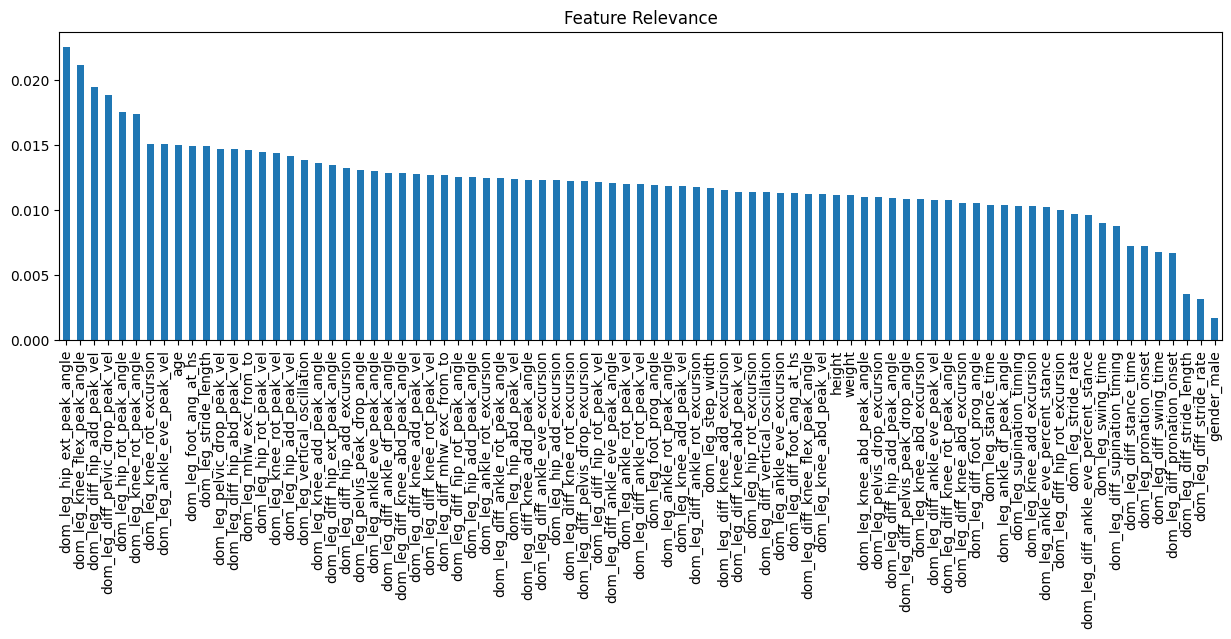

In [7]:
pd.Series(sel.relevance_, index=sel.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.title("Feature Relevance")
plt.show()

In [9]:
X_train_selected = sel.transform(X_preprocessed_df)
display(X_train_selected.head())

,age,height,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_peak_angle,...,dom_leg_mhw_exc_from_to,dom_leg_diff_mhw_exc_from_to,dom_leg_pelvic_drop_peak_vel,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_step_width,dom_leg_diff_stride_length,dom_leg_supination_timing,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,0.633105,1.447539,0.504055,1.352344,0.367857,-0.230089,-0.806429,-1.231183,...,-0.761257,-0.554392,0.077306,-0.964662,1.493426,1.983425,0.033290,0.518204,0.557382,0.334735
100002_20110601T140505,-0.150620,0.088511,-0.769343,-0.891457,-0.128827,0.772460,1.501485,0.540020,1.289326,0.001899,...,0.692156,0.881889,0.770352,0.280063,1.284626,-0.857244,0.033290,-0.383164,-0.052167,-1.015686
100004_20110203T120721,-0.326281,0.318975,-0.611548,0.952733,0.213660,-0.265570,-0.682724,-0.340104,-0.152102,1.795760,...,0.087032,0.036867,0.611224,-0.465172,1.438973,-1.532790,0.033290,-1.184380,0.321218,0.936946
100004_20140929T102035,0.025040,0.256121,-0.597585,-1.235893,-0.149788,-1.023207,-1.082561,0.209973,-0.712062,0.917178,...,-0.218099,-0.291227,1.481642,1.031569,1.536543,-0.979693,-2.375712,-1.284532,0.006865,1.274719
100005_20110208T120837,-0.501941,-1.336177,-0.055702,-0.082042,-0.504754,0.652176,-0.658743,-0.670150,-0.203652,-0.040992,...,-0.350208,-0.133575,0.820841,-0.513202,0.437588,-0.415119,0.033290,-1.484836,-1.061532,-0.356889


## Save the train-test datasets for model selection

In [10]:
X_train_selected.to_csv(c.RICKD_MODEL_1_X_TRAIN_FILE)
X_test.to_csv(c.RICKD_MODEL_1_X_TEST_FILE)
y_train.to_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE)
y_test.to_csv(c.RICKD_MODEL_1_Y_TEST_FILE)